# freight analytics 

In [76]:
import numpy as np
import pandas as pd
import ast
import networkx as nx
from tqdm import tqdm
import pickle
from scipy import stats
import matplotlib.pyplot as plt

In [43]:
# import graph
with open(r"C:\Users\prade\OneDrive\Documents\Code\TransportFever2\Data\graph\industry.pkl", "rb") as f:
    G = pickle.load(f)

In [44]:
G.nodes[7838]

{'name': ' Ranchi Iron ore mine',
 'x': -1588.0,
 'y': 3072.0,
 'z': 1.8,
 'confile': 'iron_ore_mine.con',
 'input_material': {},
 'input_proportion': [{}],
 'output_material': ['IRON_ORE'],
 'output_proportion': [1],
 'capacity': 400}

In [45]:
def get_attr(nodes, G, func):
    attr = {}
    for node in nodes:
        attr[node] = func(G.nodes[node])
    return attr

In [46]:
def plot_betweeness_hub(G, edge_weight='euclidian', cutoff=5):

    temp = nx.betweenness_centrality(G, normalized=False, weight=edge_weight)
    between_df = pd.DataFrame({
        'node': list(temp.keys()),
        'betweenness_centrality': list(temp.values())
    })
    del temp
    between_df = between_df.loc[between_df['betweenness_centrality']>cutoff]
    between_node = between_df.node.to_list()

    pos = get_attr(G.nodes, G, lambda x: (x['x'], x['y']))
    nx.draw(G, pos=pos, node_size=15, alpha=0.3)
    pos = get_attr(between_node, G, lambda x: (x['x'], x['y']))
    labels = get_attr(between_node, G, lambda x: x['name'])
    nx.draw(G.subgraph(between_node), pos=pos, 
            labels=labels, with_labels=True,
            node_size=15, node_color='salmon')

## get tier in supply chain

In [84]:
nodes = list(G.nodes())
node_df = pd.DataFrame({
    "node":nodes,
})
node_df['name'] = node_df['node'].apply(lambda x: G.nodes[x]['name'])
node_df['in_degree'] = node_df['node'].apply(lambda x: G.in_degree(x))
node_df['out_degree'] = node_df['node'].apply(lambda x: G.out_degree(x))
node_df['betweeness'] = node_df['node'].apply(lambda x: nx.betweenness_centrality(G, normalized=False, weight='euclidian')[x])


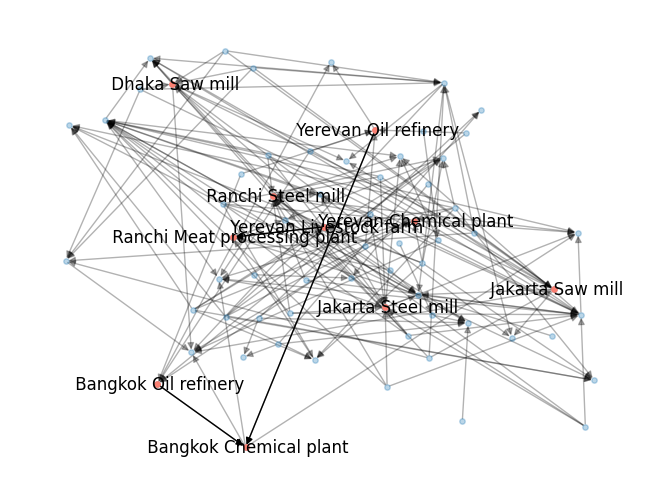

In [48]:
plot_betweeness_hub(G)

In [85]:
def descendants_avg_len(source):
    dist = []
    for target in nx.descendants(G, source=source):
        dist.append(nx.shortest_path_length(G, source=source, target=target, weight='euclidian'))
    return round(np.mean(dist).item(), 3)

In [86]:
node_df['len_descendants'] = node_df['node'].apply(lambda x: len(nx.descendants(G, source=x)))
node_df['descendants_avg_len'] = node_df['node'].apply(lambda x: descendants_avg_len(x))


c:\Users\prade\miniconda3\envs\dev_env\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\prade\miniconda3\envs\dev_env\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [87]:
node_df['between_perctle'] = (node_df['betweeness'] - node_df['betweeness'].min()) / (node_df['betweeness'].max() - node_df['betweeness'].min())
node_df['descendants_perctle'] = (node_df['descendants_avg_len'] - node_df['descendants_avg_len'].min()) / (node_df['descendants_avg_len'].max() - node_df['descendants_avg_len'].min())

In [ ]:
node_df.dropna(inplace=True)
node_df = node_df.loc[node_df['betweeness']>0]

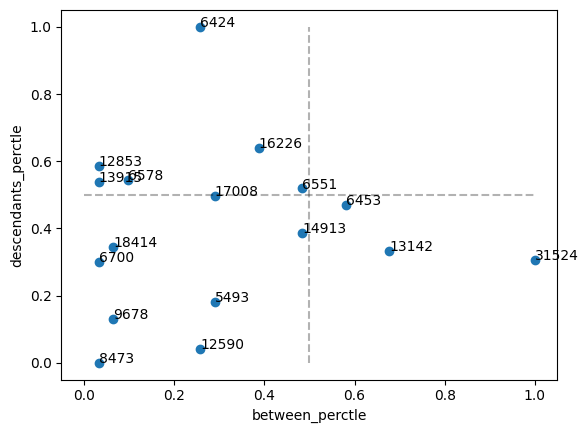

In [93]:
plt.scatter(node_df['between_perctle'], node_df['descendants_perctle'])
plt.xlabel('between_perctle')
plt.ylabel('descendants_perctle')
plt.plot([0.5]*2,[0,1], 'k--', alpha=0.3)
plt.plot([0,1],[0.5]*2, 'k--', alpha=0.3)

for i, row in node_df.iterrows():
    plt.annotate(row['node'], (row['between_perctle'], row['descendants_perctle']))

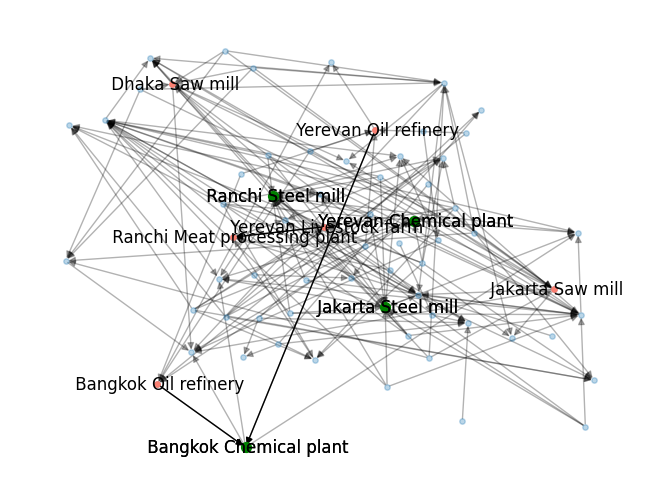

In [108]:
plot_betweeness_hub(G, edge_weight='euclidian', cutoff=5)
lst = [6453, 31524, 13142, 14913]
pos = get_attr(lst, G, lambda x: (x['x'], x['y']))
labels = get_attr(lst, G, lambda x: x['name'])
nx.draw(G.subgraph(lst), pos=pos, 
            labels=labels, with_labels=True,
            node_size=50, node_color='green')


In [110]:
labels

{6453: ' Bangkok Chemical plant',
 31524: ' Ranchi Steel mill',
 13142: ' Jakarta Steel mill',
 14913: ' Yerevan Chemical plant'}

In [96]:
pos

{31524: (-1464.0, 1808.0)}

In [69]:
node_df.columns

Index(['node', 'name', 'in_degree', 'out_degree', 'betweeness',
       'len_descendants', 'descendants_avg_len', 'between_perctle'],
      dtype='object')

In [ ]:
node_df

{5492, 5643, 5915, 6578, 7098, 8858, 9570, 12853, 13142, 29971, 31524}

In [56]:
nx.shortest_path_length(G, source=7838, target=5492, weight='euclidian')

4133.13

In [51]:
G.nodes[7838]

{'name': ' Ranchi Iron ore mine',
 'x': -1588.0,
 'y': 3072.0,
 'z': 1.8,
 'confile': 'iron_ore_mine.con',
 'input_material': {},
 'input_proportion': [{}],
 'output_material': ['IRON_ORE'],
 'output_proportion': [1],
 'capacity': 400}